## Simple Notebook Example

Here we introduce the idea of creating a domain which contains the mesh and quantities needed to run the simulation, and encapsulates the methods for setting up the initial conditions, the boundary conditions and the method for evolving the solution.

### Setup Notebook for Visualisation and Animation

We are using the format of a jupyter notebook. As such we need to setup inline matplotlib plotting and animation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Allow inline jshtml animations
from matplotlib import rc
rc('animation', html='jshtml')

### Import ANUGA

We assume that anuga has been installed. If so we can import anuga. 

In [2]:
import anuga

### Create an ANUGA domain

A Domain is the core object which contains the mesh and the quantities for the particular problem. Here we create a simple rectangular Domain. We set the name to `domain1` which will be used when storing the simulation output to a sww file called `domain1.sww`.

In [3]:
domain = anuga.rectangular_cross_domain(40, 20, len1=20.0, len2=10.0)

domain.set_name('domain1')
domain.set_store_vertices_smoothly(False)

### Plot Mesh

Let's look at the mesh. We will use some code derived form the clawpack project to simplify plotting and animation of the output from our simulations. This is available via the animate module loaded from anuga and intergated into the domain class.

The `set_plotter` routines provides simple access to the centroid values of our evolution quantities, `stage`, `depth`, `elev`, `xmon` and `ymon` and the triangulation `triang`.

Note: This visualisation is recommended for smaller domains (maybe up to 10,000 triangles). We have an `anuga-viewer` for larger domains.

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Easting (m)', ylabel='Northing (m)'>,
  <matplotlib.lines.Line2D at 0x7f8877f51550>])

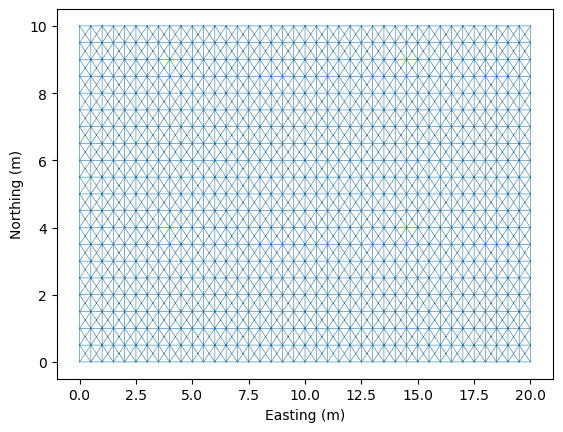

In [4]:
# this method takes the same arguments as the standard matplotlib procedure triplot.
domain.triplot(linewidth = 0.4)

### Setup Initial Conditions

We have to setup the values of various quantities associated with the domain. In particular we need to setup the elevation the elevation of the bed or the bathymetry. In this case we will do this using a function.

In [5]:
def topography(x, y):

    z = -x/10

    N = len(x)
    
    minx = np.floor(np.max(x)/4)
    wallx1 = np.min(x[(x >= minx)])
    wallx2 = np.min(x[(x > wallx1 + 0.25)])
    
    minx = np.floor(np.max(x)/2)
    wallx3 = np.min(x[(x >= minx)])
    wallx4 = np.min(x[(x > wallx3 + 0.25)])
    
    minx = np.floor(3*np.max(x)/4)
    wallx5 = np.min(x[(x >= minx)])
    wallx6 = np.min(x[(x > wallx5 + 0.25)])
    
    dist = 0.4 * (np.max(y) - np.min(y))
    
    for i in range(N):
        if wallx1 <= x[i] <= wallx2:
            if (y[i] < dist):
                z[i] += 1
                
        if wallx3 <= x[i] <= wallx4:
            if (y[i] > np.max(y) - dist):
                z[i] += 1
                
        if wallx5 <= x[i] <= wallx6:
            if (y[i] < dist):
                z[i] += 1
            
    return z

### Set Quantities

Now we set the `elevation`, `stage` and `friction` using the `domain.set_quantity` function.

In [6]:
domain.set_quantity('elevation', topography, location='centroids')         # Use function for elevation
domain.set_quantity('friction', 0.01, location='centroids')                # Constant friction 
domain.set_quantity('stage', expression='elevation', location='centroids') # Dry Bed 

### View Elevation

Let's use the matplotlib function `tripcolor` (built into the `Domain` class) to plot the elevation quantity. 

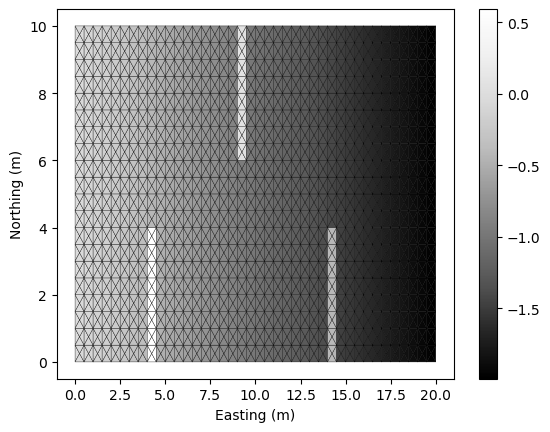

In [9]:
fig, ax, im = domain.tripcolor(
              facecolors = domain.elev, 
              edgecolors='k', 
              cmap='Greys_r')
plt.colorbar(im, ax=ax);

Notice that we have been very careful to match up the defintion of the topography via the function `topography` with the resolution of the mesh. 

### Setup Boundary Conditions

The rectangular domain has 4 tagged boundaries, left, top, right and bottom. We need to set boundary conditons for each of these tagged boundaries. We can set `Dirichlet_boundary` type BC with specified values of stage, and x and y "momentum". Another common BC is `Reflective_boundary` which mimics a wall.

In [10]:
Bi = anuga.Dirichlet_boundary([0.4, 0, 0])         # Inflow
Bo = anuga.Dirichlet_boundary([-2, 0, 0])          # Outflow
Br = anuga.Reflective_boundary(domain)            # Solid reflective wall

domain.set_boundary({'left': Bi, 'right': Bo, 'top': Br, 'bottom': Br})

### Run the Evolution

We evolve using a for statement, which evolves the quantities using the ANUGA shallow water wave solver. The calculation yields every `yieldstep` seconds, for a given `duration` (or until a specified `finaltime`).

In [11]:
for t in domain.evolve(yieldstep=2, duration=40):
  
    #domain.plot_depth_frame()
    domain.save_depth_frame(vmin=0.0,vmax=1.0)
    
    domain.print_timestepping_statistics()

    
# Read in the png files stored during the evolve loop
domain.make_depth_animation() 

Time = 0.0000 (sec), steps=0 (0s), elapsed (0s), eta (??), mem=224MB
Time = 2.0000 (sec), delta t in [0.01779464, 0.03749219] (s), steps=93 (0s), elapsed (0s), eta (8s), mem=227MB
Time = 4.0000 (sec), delta t in [0.01523410, 0.01780455] (s), steps=123 (0s), elapsed (0s), eta (7s), mem=229MB
Time = 6.0000 (sec), delta t in [0.01509139, 0.01543878] (s), steps=132 (0s), elapsed (1s), eta (6s), mem=232MB
Time = 8.0000 (sec), delta t in [0.01543945, 0.01589701] (s), steps=129 (0s), elapsed (1s), eta (5s), mem=235MB
Time = 10.0000 (sec), delta t in [0.01510457, 0.01595656] (s), steps=129 (0s), elapsed (1s), eta (5s), mem=238MB
Time = 12.0000 (sec), delta t in [0.01448747, 0.01510270] (s), steps=136 (0s), elapsed (2s), eta (5s), mem=241MB
Time = 14.0000 (sec), delta t in [0.01416889, 0.01448641] (s), steps=140 (0s), elapsed (2s), eta (4s), mem=245MB
Time = 16.0000 (sec), delta t in [0.01390842, 0.01416679] (s), steps=143 (0s), elapsed (2s), eta (4s), mem=248MB
Time = 18.0000 (sec), delta t in